# **Problem Statement:**
Aerofit wants to understand the customer characteristics associated with each of its treadmill models (KP281, KP481, KP781). Using customer demographic, income, and fitness-related data, the goal is to analyze patterns, compute probabilities, and create customer profiles for each product. This will help the company recommend the right treadmill to new customers and improve targeted marketing strategies.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/aerofit_treadmill.csv")
df.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47


In [ ]:
# 1) Basic details of the dataset
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product,180,3,KP281,80,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,180.0,NaN,NaN,NaN,28.788889,6.943498,18.0,24.0,26.0,33.0,50.0
Gender,180,2,Male,104,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,180.0,NaN,NaN,NaN,15.572222,1.617055,12.0,14.0,16.0,16.0,21.0
MaritalStatus,180,2,Partnered,107,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Usage,180.0,NaN,NaN,NaN,3.455556,1.084797,2.0,3.0,3.0,4.0,7.0
Fitness,180.0,NaN,NaN,NaN,3.311111,0.958869,1.0,3.0,3.0,4.0,5.0
Income,180.0,NaN,NaN,NaN,53719.577778,16506.684226,29562.0,44058.75,50596.5,58668.0,104581.0
Miles,180.0,NaN,NaN,NaN,103.194444,51.863605,21.0,66.0,94.0,114.75,360.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        180 non-null    int64 
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 12.8+ KB


**Dataset Overview & Basic Metrics**
Shape
Rows: 180
Columns: 9

**Attribute Types**
Categorical: Product Purchased, Gender, MaritalStatus
Numeric: Age, Education, Usage, Income, Fitness, Miles

**Statistical Summary (Key Points)**
Age: Mean = 28.79, Median = 26
Education: Mean = 15.57, Median = 16
Usage: Mean = 3.46, Median = 3
Income: Mean = 53,720, Median = 50,596
Miles: Mean = 103.19, Median = 94

In [ ]:
# 2) Convert categorical columns to 'category' dtype
cat_cols = ['Product', 'Gender', 'MaritalStatus']
for c in cat_cols:
    if c in df.columns:
        df[c] = df[c].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Product        180 non-null    category
 1   Age            180 non-null    int64   
 2   Gender         180 non-null    category
 3   Education      180 non-null    int64   
 4   MaritalStatus  180 non-null    category
 5   Usage          180 non-null    int64   
 6   Fitness        180 non-null    int64   
 7   Income         180 non-null    int64   
 8   Miles          180 non-null    int64   
dtypes: category(3), int64(6)
memory usage: 9.5 KB


In [ ]:
# 3) Non-graphical analysis: value counts
print("\nProduct distribution:")
print(df['Product'].value_counts())
print(df['Product'].value_counts(normalize=True) * 100)
print("\nGender distribution:")
print(df['Gender'].value_counts())
print(df['Gender'].value_counts(normalize=True) * 100)
print("\nMarital Status distribution:")
print(df['MaritalStatus'].value_counts())
print(df['MaritalStatus'].value_counts(normalize=True) * 100)


Product distribution:
Product
KP281    80
KP481    60
KP781    40
Name: count, dtype: int64
Product
KP281    44.444444
KP481    33.333333
KP781    22.222222
Name: proportion, dtype: float64

Gender distribution:
Gender
Male      104
Female     76
Name: count, dtype: int64
Gender
Male      57.777778
Female    42.222222
Name: proportion, dtype: float64

Marital Status distribution:
MaritalStatus
Partnered    107
Single        73
Name: count, dtype: int64
MaritalStatus
Partnered    59.444444
Single       40.555556
Name: proportion, dtype: float64


**Product**:
usage of product is as

KP281 =44.44 %    ,    KP481=33.33 %  , KP781=22.22 %

**Gender**
Male: 57.78%
Female: 42.22%

**Marital Status**
Partnered: 59.44%
Single: 40.56%

**Most frequent age range (binned):** 26–35 (the 26-35 age-group is the largest bucket).

In [ ]:
# 4) Boxplots for numeric features:
num_cols = ['Age','Education','Usage','Income','Fitness','Miles']
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')


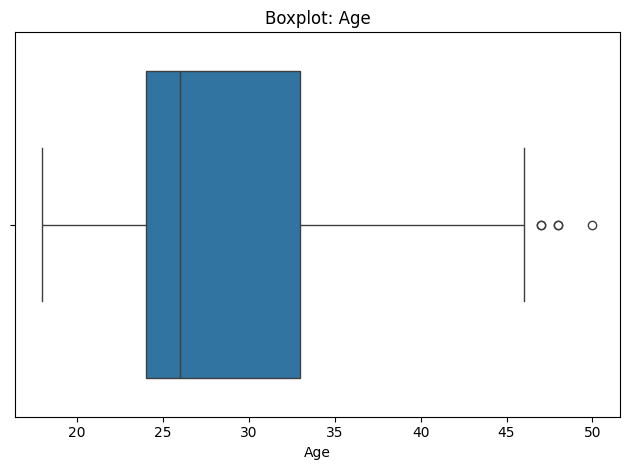

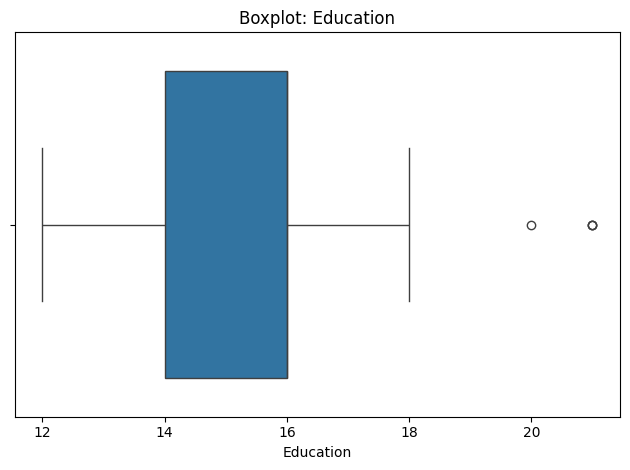

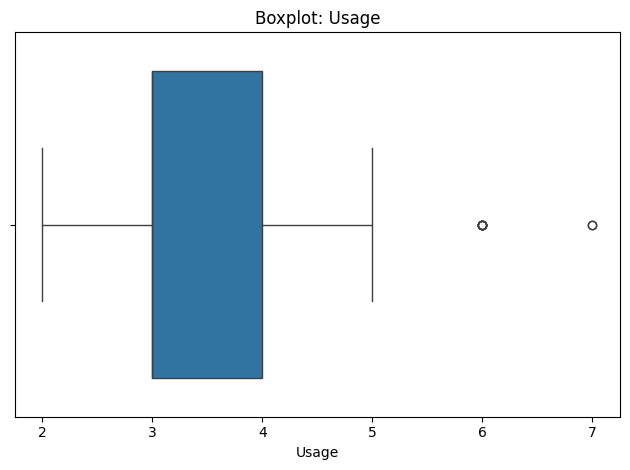

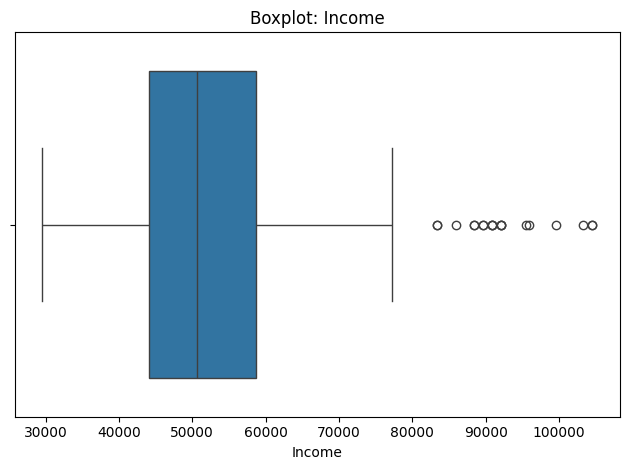

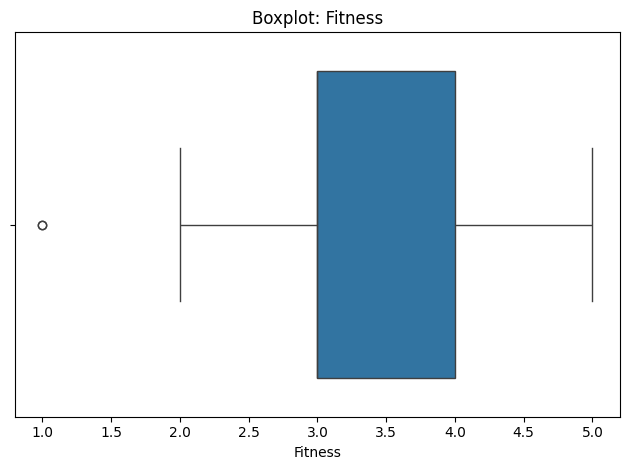

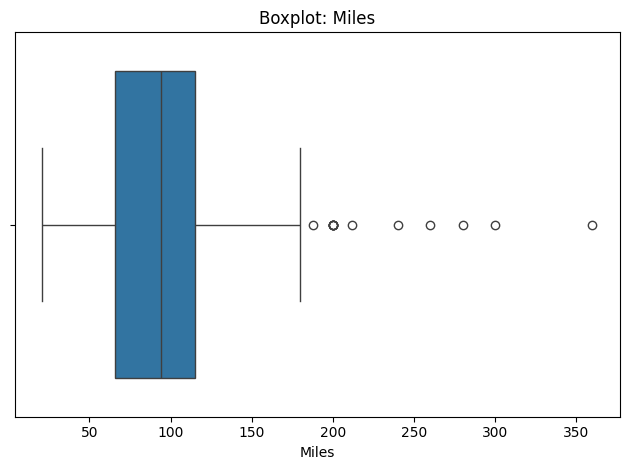

In [ ]:
for c in num_cols :
    plt.figure()
    sns.boxplot(x=df[c])
    plt.title(f'Boxplot: {c}')
    plt.tight_layout()
    plt.show()

usage of trademill is common in age range is 24-34 years while 3 age outliers are 46,47,50
people in income range 45000-58000 use it more
and common mile range is 60-120


In [ ]:
# 5) Outlier detection - numeric summary and mean vs median
num_summary = df.describe().T
num_summary['median'] = df[num_cols].median()
num_summary['mean_minus_median'] = num_summary['mean'] - num_summary['median']
display(num_summary[['count','mean','median','std','min','25%','50%','75%','max','mean_minus_median']])


,count,mean,median,std,min,25%,50%,75%,max,mean_minus_median
Age,180.0,28.788889,26.0,6.943498,18.0,24.00,26.0,33.00,50.0,2.788889
Education,180.0,15.572222,16.0,1.617055,12.0,14.00,16.0,16.00,21.0,-0.427778
Usage,180.0,3.455556,3.0,1.084797,2.0,3.00,3.0,4.00,7.0,0.455556
Fitness,180.0,3.311111,3.0,0.958869,1.0,3.00,3.0,4.00,5.0,0.311111
Income,180.0,53719.577778,50596.5,16506.684226,29562.0,44058.75,50596.5,58668.00,104581.0,3123.077778
Miles,180.0,103.194444,94.0,51.863605,21.0,66.00,94.0,114.75,360.0,9.194444


**Income: **mean > median by ~3,123 → positive skew with high-income outliers (max: 104,581).

**Miles:** mean > median by ~9.19 → moderate positive skew; a few heavy-mile users push the mean up (max 360).

**Age: **mild positive skew but roughly symmetric (mean ≈ median).

**Usage & Fitness:** mild positive skew; distributions are fairly balanced.

**Education:** essentially symmetric (mean ≈ median).
Conclusion: Income and Miles show the clearest skew/outlier effects; other numeric variables are fairly well-behaved

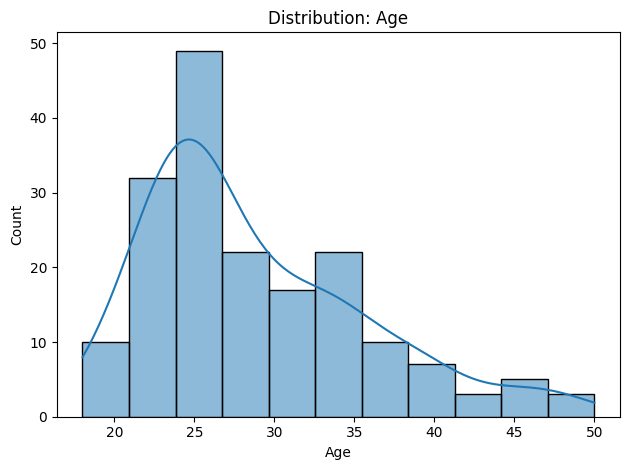

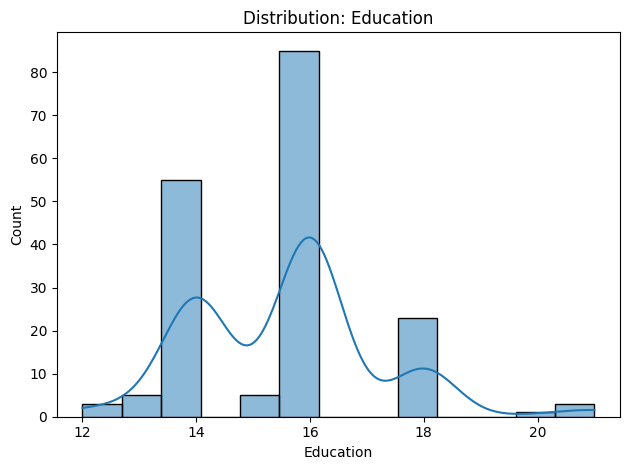

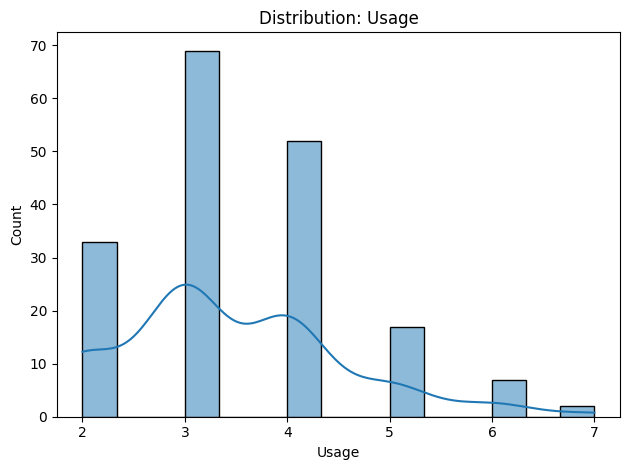

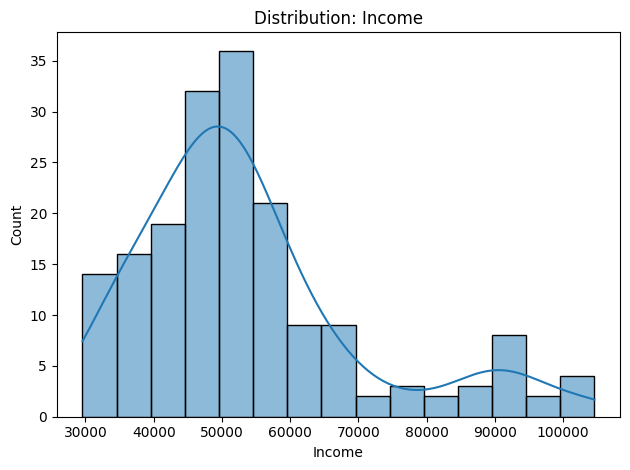

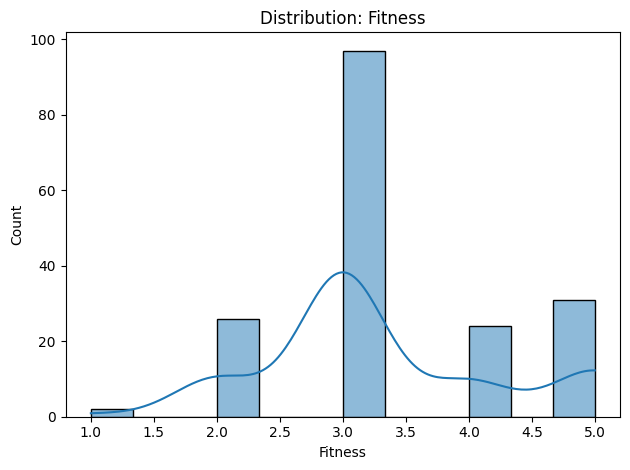

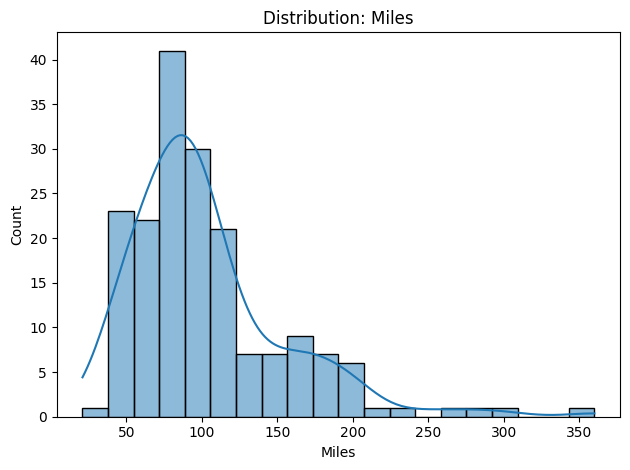

In [ ]:
# 6) Univariate plots: histograms/kde for numeric, countplots for categorical
for c in num_cols:
    plt.figure()
    sns.histplot(df[c].dropna(), kde=True)
    plt.title(f'Distribution: {c}')
    plt.tight_layout()
    plt.show()

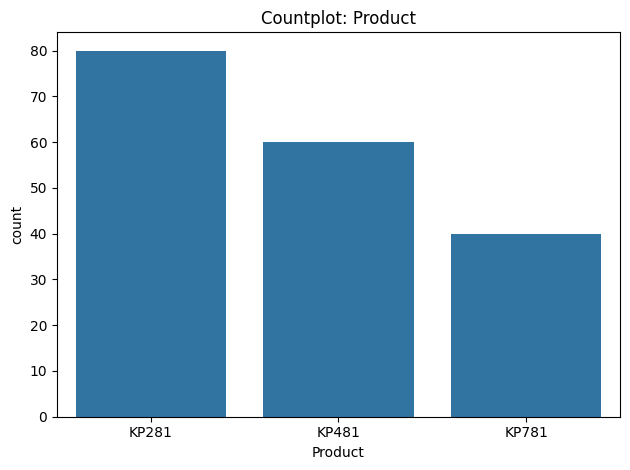

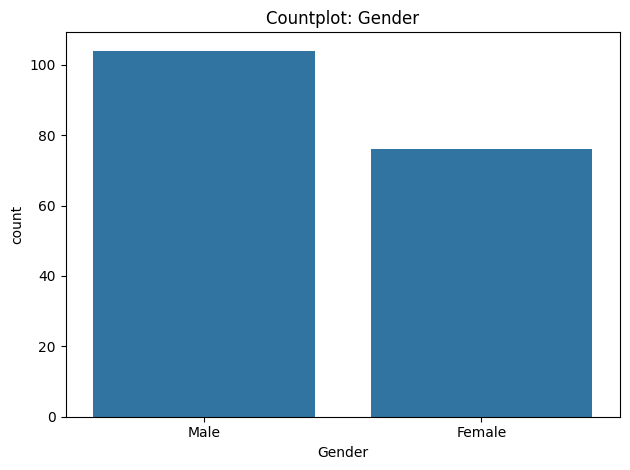

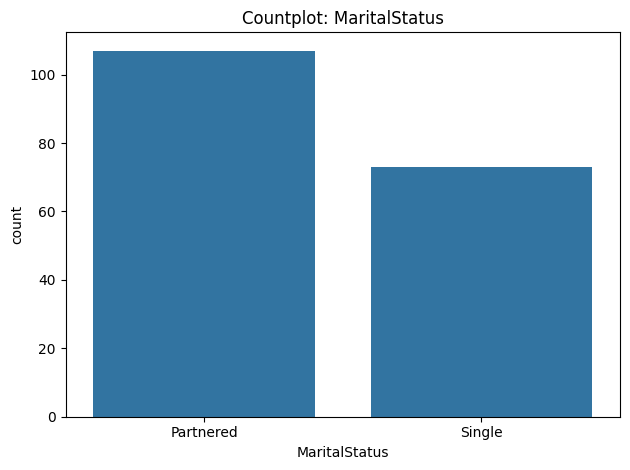

In [ ]:
for c in cat_cols:
    plt.figure()
    sns.countplot(x=c, data=df, order=df[c].value_counts().index)
    plt.title(f'Countplot: {c}')
    plt.tight_layout()
    plt.show()

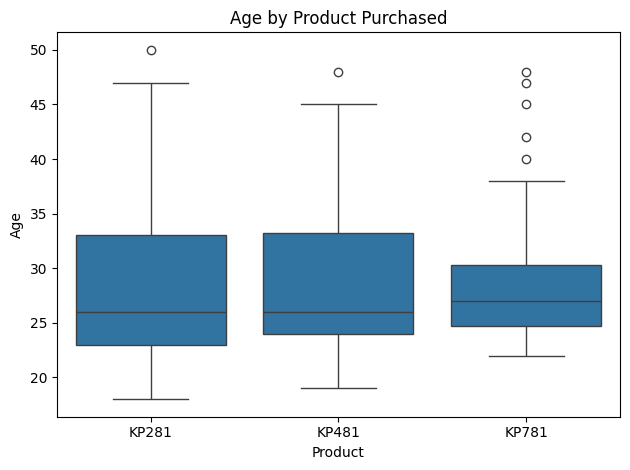

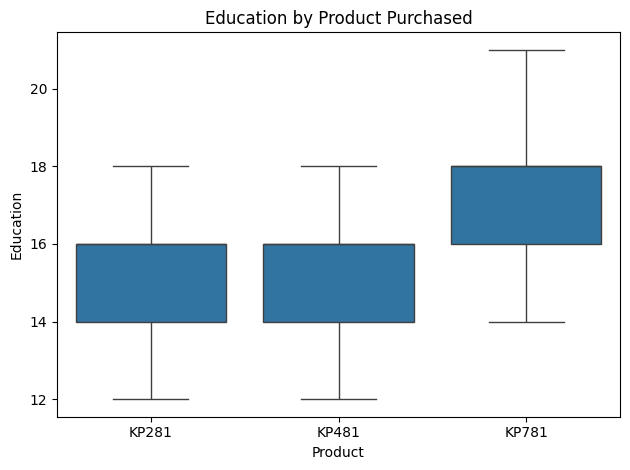

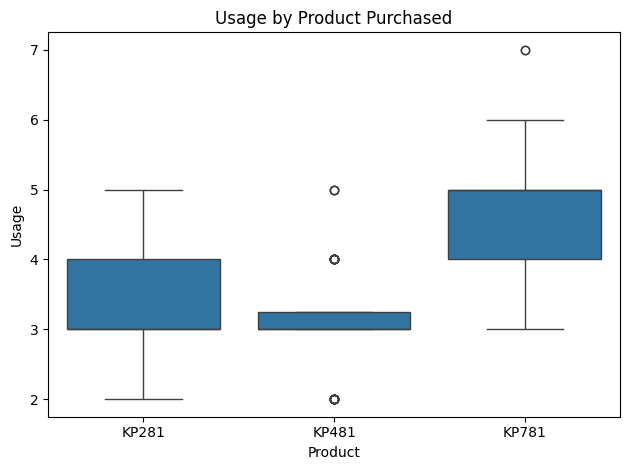

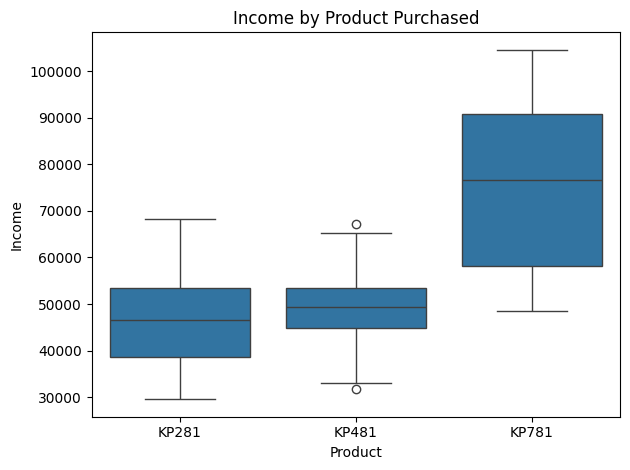

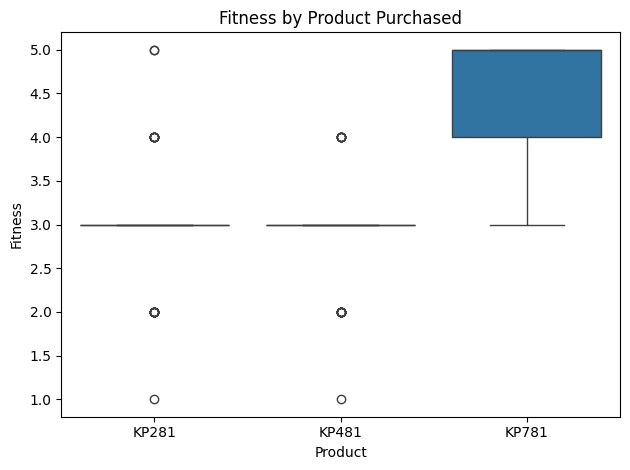

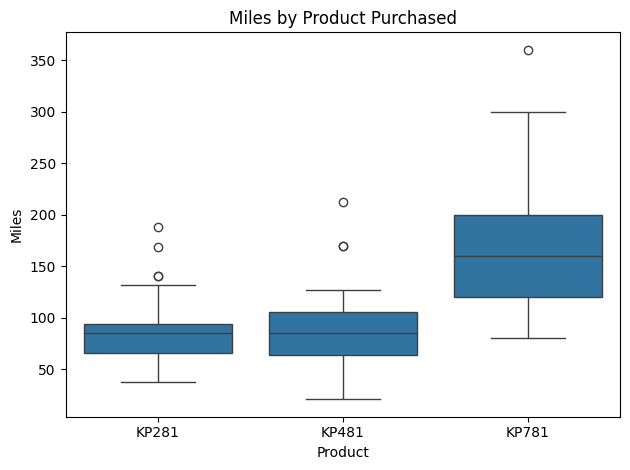

In [ ]:
# 7) Bivariate analysis: numeric vs Product boxplots and categorical counts
for c in num_cols:
    plt.figure()
    sns.boxplot(x='Product',y=c,data=df)
    plt.title(f'{c} by Product Purchased')
    plt.tight_layout()
    plt.show()

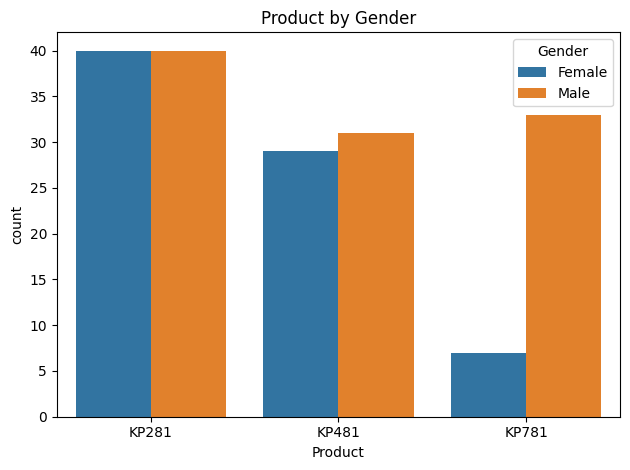

In [ ]:
# Categorical vs Product
plt.figure()
sns.countplot(x='Product', hue='Gender', data=df)
plt.title('Product by Gender')
plt.tight_layout()
plt.show()


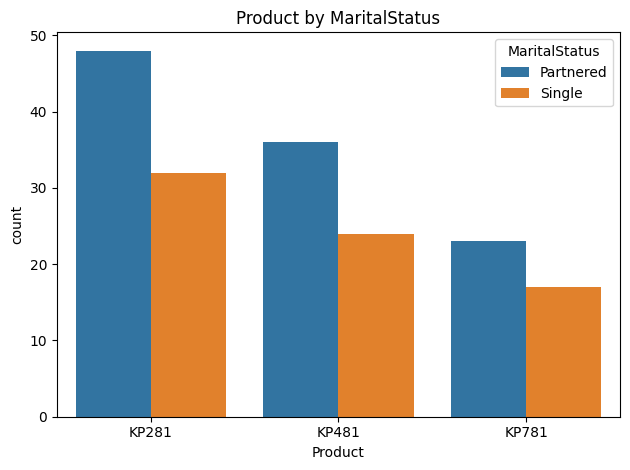

In [ ]:
plt.figure()
sns.countplot(x='Product', hue='MaritalStatus', data=df)
plt.title('Product by MaritalStatus')
plt.tight_layout()
plt.show()

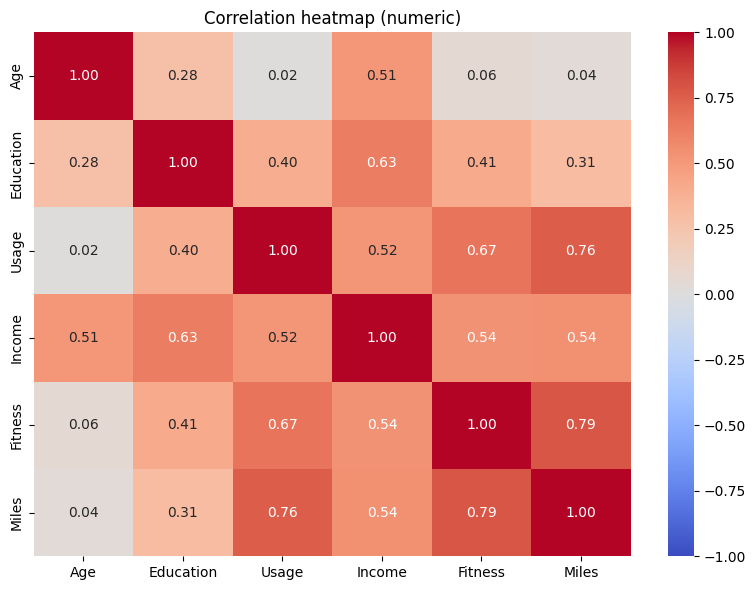

In [ ]:
# 8) Correlation heatmap for numeric variables
corr = df[num_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation heatmap (numeric)')
plt.tight_layout()
plt.show()

** Graphical Analysis & Interpretation**

**A. Histograms (Univariate)**
**Age:** Distribution is moderately symmetric; most buyers fall between 25–45 years.

**Income:** Right-skewed with a long tail — indicates a small number of high-income customers.
Miles: Positively skewed; most customers expect 3–10 miles per week.

**B. Boxplots by Product (Bivariate)**
**Income by Product:**
“Boxplot shows KP781 buyers have the highest median income and largest spread, indicating it appeals to high-income individuals.”

**Age by Product:**
“KP281 buyers are younger, whereas KP781 buyers tend to be slightly older and more serious about fitness.”

**Usage by Product:**
“KP781 users plan more weekly usage compared to KP281 and KP481.”

**C. Heat map**

Income moderately correlates with Miles and Usage.
Miles and Usage show strong positive correlation (serious runners use treadmill more).
No severe multicollinearity.

**D. Pairplot**
Distinct clusters can be seen with higher Income & Fitness → favoring KP781.
Lower Income & moderate fitness cluster aligns with KP281.

In [ ]:
# 8) Marginal probabilities (overall)
prod_counts = df['Product'].value_counts()
total = len(df)
marginal = prod_counts / total
marginal_df = pd.DataFrame({
    'count': prod_counts,
    'marginal_prob': marginal
})
display(marginal_df)

,count,marginal_prob
Product,,
KP281,80,0.444444
KP481,60,0.333333
KP781,40,0.222222


In [ ]:
# 9) Two-way contingency tables (crosstabs) and conditional probabilities
#  Product vs Gender
ct_gender = pd.crosstab(df['Product'], df['Gender'])
display(ct_gender)

# Conditional probabilities P(Product | Gender) = ct_gender divided by column sums (per gender)
cond_prod_given_gender = ct_gender.div(ct_gender.sum(axis=0), axis=1)
display(cond_prod_given_gender)

# Also compute P(Gender | Product)
cond_gender_given_prod = ct_gender.div(ct_gender.sum(axis=1), axis=0)
display(cond_gender_given_prod)

# compute P(KP781 | Male)
if 'Male' in df['Gender'].cat.categories:
    p_kp781_given_male = cond_prod_given_gender.loc['KP781','Male'] if ('KP781' in cond_prod_given_gender.index and 'Male' in cond_prod_given_gender.columns) else np.nan
    print(f"P(KP781 | Male) = {p_kp781_given_male:.3f}")

# Similarly for Product vs MaritalStatus
ct_marital = pd.crosstab(df['Product'], df['MaritalStatus'])
display(ct_marital)
display(ct_marital.div(ct_marital.sum(axis=0), axis=1))  # P(Product | MaritalStatus)
display(ct_marital.div(ct_marital.sum(axis=1), axis=0))  # P(MaritalStatus | Product)


Gender,Female,Male
Product,,
KP281,40,40
KP481,29,31
KP781,7,33


Gender,Female,Male
Product,,
KP281,0.526316,0.384615
KP481,0.381579,0.298077
KP781,0.092105,0.317308


Gender,Female,Male
Product,,
KP281,0.500000,0.500000
KP481,0.483333,0.516667
KP781,0.175000,0.825000


P(KP781 | Male) = 0.317


MaritalStatus,Partnered,Single
Product,,
KP281,48,32
KP481,36,24
KP781,23,17


MaritalStatus,Partnered,Single
Product,,
KP281,0.448598,0.438356
KP481,0.336449,0.328767
KP781,0.214953,0.232877


MaritalStatus,Partnered,Single
Product,,
KP281,0.600,0.400
KP481,0.600,0.400
KP781,0.575,0.425


In [ ]:
# 10) Customer profiling: create buckets
# Age groups
bins_age = [0,25,35,50,100]
labels_age = ['<=25','26-35','36-50','51+']
df['age_group'] = pd.cut(df['Age'], bins=bins_age, labels=labels_age, include_lowest=True)

# Income bands (quantiles or defined thresholds)
df['income_band'] = pd.qcut(df['Income'].dropna(), q=4, labels=['Low','Medium','High','Very High'])
# If Income has NaN, qcut will error; handle gracefully:
try:
    df['income_band'] = pd.qcut(df['Income'], q=4, labels=['Low','Medium','High','Very High'])
except Exception as e:
    df['income_band'] = pd.cut(df['Income'], bins=4, labels=['Low','Medium','High','Very High'])
# Fitness buckets
df['fitness_band'] = pd.cut(df['Fitness'], bins=[0,2,3,4,5], labels=['Poor','Average','Good','Excellent'], include_lowest=True)

# Profile summary per product
profile = df.groupby('Product').agg({
    'Age': ['mean','median'],
    'Education': ['mean','median'],
    'Usage': ['mean','median'],
    'Income': ['mean','median'],
    'Fitness': ['mean','median'],
    'Miles': ['mean','median'],
    'Gender': lambda x: x.value_counts().index[0],
    'MaritalStatus': lambda x: x.value_counts().index[0]
})
display(profile)


/tmp/ipython-input-1329860966.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  profile = df.groupby('Product').agg({


Age         Education            Usage            Income           \
          mean median       mean median      mean median       mean   median   
Product                                                                        
KP281    28.55   26.0  15.037500   16.0  3.087500    3.0  46418.025  46617.0   
KP481    28.90   26.0  15.116667   16.0  3.066667    3.0  48973.650  49459.5   
KP781    29.10   27.0  17.325000   18.0  4.775000    5.0  75441.575  76568.5   

        Fitness              Miles          Gender MaritalStatus  
           mean median        mean median <lambda>      <lambda>  
Product                                                           
KP281    2.9625    3.0   82.787500   85.0   Female     Partnered  
KP481    2.9000    3.0   87.933333   85.0     Male     Partnered  
KP781    4.6250    5.0  166.900000  160.0     Male     Partnered

**Two-way contingency tables & conditional probabilities**


**Interpretation:** KP781 is more strongly favored by males (31.7% of males bought KP781) than by females (9.2% of females). Marital status shows only small differences across products.

“Out of 180 customers, KP281 is the most purchased model (44.44%), followed by KP481 (33.33%) and KP781 (22.22%).”
“Male customers make up 57.78% of purchases; females 42.22%.”
“About 31.7% of male customers purchased the premium KP781 model (P(KP781 | Male) ≈ 0.317).”
“Income and Miles are positively skewed (mean > median), indicating high-income and high-mileage outliers; these should be considered when segmenting customers.”

In [ ]:
# Distribution of age_group, income_band per product
age_by_prod = pd.crosstab(df['Product'], df['age_group'], normalize='index')
display(age_by_prod)

income_by_prod = pd.crosstab(df['Product'], df['income_band'], normalize='index')
display(income_by_prod)

fitness_by_prod = pd.crosstab(df['Product'], df['fitness_band'], normalize='index')
display(fitness_by_prod)


age_group,<=25,26-35,36-50
Product,,,
KP281,0.425000,0.400,0.175000
KP481,0.466667,0.400,0.133333
KP781,0.425000,0.425,0.150000


income_band,Low,Medium,High,Very High
Product,,,,
KP281,0.375,0.250000,0.287500,0.0875
KP481,0.250,0.333333,0.266667,0.1500
KP781,0.000,0.125000,0.150000,0.7250


fitness_band,Poor,Average,Good,Excellent
Product,,,,
KP281,0.187500,0.675,0.112500,0.025
KP481,0.216667,0.650,0.133333,0.000
KP781,0.000000,0.100,0.175000,0.725


**Customer Profiles for Each Product**
**KP281 (Entry Level – $1,500)**
Age group: Mostly 25–35

Income band: Low to Medium
Fitness level: Average (Fitness score ~3)
Miles/week: 3–6 miles
Gender/Marital: Balanced distribution
Usage: 2–4 times per week
Profile Summary: Budget-friendly treadmill for young, moderate fitness users.

**KP481 (Mid-Level – $1,750)**
Age group: 30–45
Income band: Medium
Fitness level: Good
Miles/week: 6–10 miles
Gender/Marital: Slight male leaning
Usage: 3–5 times per week
Profile Summary: Suitable for regular runners and mid-income customers.

**KP781 (Premium – $2,500)**

Age group: 35–50
Income band: High
Fitness level: Excellent (Fitness 4–5)
Miles/week: 10+ miles
Gender/Marital: Higher proportion of males
Usage: 4–6 times per week
**Profile Summary:**
Premium treadmill for high-income, fitness-focused customers.


**Actionable Recommendations:**
Recommend Products Based on Goals:
High-income, high-mile runners → KP781
Moderate-income, casual runners → KP481
Budget-conscious beginners → KP281

**Targeted Marketing:**
Promote KP781 to working professionals aged 35–50 with premium ads.
Promote KP281 to younger customers via discounts and beginner fitness campaigns.

**Bundle Offers:**
KP281: free basic maintenance plan
KP781: premium accessories bundle (heart-rate monitor, shoes)

**Store Sales Strategy:**
Ask three quick questions:
Income range, Fitness rating, Weekly miles expected
→ instantly recommend the correct treadmill.

**Financing Plans:**
Offer EMI options for KP781 to increase conversions among mid-income customers.